<a href="https://colab.research.google.com/github/MVpranav168/2-link-robot-ml/blob/main/01_robot_arm_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

print("Libraries loaded succesfully!")



Libraries loaded succesfully!


In [2]:
L1 = 30
L2 = 15

print("Link 1:", L1,"cm")
print("Link 2:", L2,"cm")

Link 1: 30 cm
Link 2: 15 cm


In [3]:
np.random.seed(25)

n_samples = 5

q1 =np.random.uniform(-np.pi,np.pi,n_samples)
q2 =np.random.uniform(-np.pi,np.pi,n_samples)

print("q1:")
print(q1)

print("\nq2:")
print(q2)

q1:
[ 2.32555854  0.51696119 -1.38959592 -1.97347793 -0.55857437]

q2:
[-2.40410034  1.1621929  -0.39200127  0.35329927 -0.83515897]


In [4]:
x = L1*np.cos(q1) + L2*np.cos(q1+q2)
y = L1*np.sin(q1) + L2*np.sin(q1+q2)

print("x positions(cm):")
print(x)

print("\ny positions(cm):")
print(y)

x positions(cm):
[ -5.59970655  24.45756528   2.2676672  -12.49703983  28.08243439]

y positions(cm):
[ 20.67611817  29.73924689 -44.17679705 -42.58211663 -30.6648125 ]


In [5]:
df = pd.DataFrame({
    "q1_rad": q1,
    "q2_rad": q2,
    "x_cm": x,
    "y_cm": y
})

df

,q1_rad,q2_rad,x_cm,y_cm
0,2.325559,-2.404100,-5.599707,20.676118
1,0.516961,1.162193,24.457565,29.739247
2,-1.389596,-0.392001,2.267667,-44.176797
3,-1.973478,0.353299,-12.497040,-42.582117
4,-0.558574,-0.835159,28.082434,-30.664813


In [6]:
np.random.seed(42)

n_samples = 5000

q1 = np.random.uniform(-np.pi, np.pi, n_samples)
q2 = np.random.uniform(-np.pi, np.pi, n_samples)

x = L1 * np.cos(q1) + L2 * np.cos(q1 + q2)
y = L1 * np.sin(q1) + L2 * np.sin(q1 + q2)

df = pd.DataFrame({
    "q1_rad": q1,
    "q2_rad": q2,
    "x_cm": x,
    "y_cm": y
})

print("Dataset shape:", df.shape)

Dataset shape: (5000, 4)


In [7]:
df.head()

,q1_rad,q2_rad,x_cm,y_cm
0,-0.788288,-0.668308,22.861112,-36.176703
1,2.831922,-0.166909,-41.901552,16.023505
2,1.457661,2.227687,-9.449753,22.047911
3,0.619890,-1.005282,38.318043,11.789514
4,-2.161299,2.322577,-1.898009,-22.511125


In [8]:
x = df[["q1_rad", "q2_rad"]]
y = df[["x_cm", "y_cm"]]

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (5000, 2)
y shape: (5000, 2)


In [9]:
print("x:")
print(x.head())

print("\ny:")
print(y.head())
#

x:
     q1_rad    q2_rad
0 -0.788288 -0.668308
1  2.831922 -0.166909
2  1.457661  2.227687
3  0.619890 -1.005282
4 -2.161299  2.322577

y:
        x_cm       y_cm
0  22.861112 -36.176703
1 -41.901552  16.023505
2  -9.449753  22.047911
3  38.318043  11.789514
4  -1.898009 -22.511125


In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42

    )

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


x_train shape: (4000, 2)
x_test shape: (1000, 2)
y_train shape: (4000, 2)
y_test shape: (1000, 2)


In [11]:
model = RandomForestRegressor(n_estimators=200,
                              random_state=42,n_jobs=-1)

model.fit(x_train,y_train)
print("Model Training Completed!!!")

Model Training Completed!!!


In [12]:
y_pred = model.predict(x_test)

print("Prediction shape:",y_pred.shape)


Prediction shape: (1000, 2)


In [13]:
comparison =pd.DataFrame({
    "actual_x_cm":y_test["x_cm"].values,
    "predicted_x_cm":y_pred[:,0],
    "actual_y_cm":y_test["y_cm"].values,
    "predicted_y_cm":y_pred[:,1]
})
comparison.head(10)


,actual_x_cm,predicted_x_cm,actual_y_cm,predicted_y_cm
0,15.771045,15.787073,-9.368614,-9.215050
1,-41.966234,-41.605645,-12.060622,-11.863178
2,-18.494907,-18.820013,-20.963727,-21.398358
3,26.071136,23.760737,-36.666350,-37.869016
4,-30.472323,-30.488024,16.881760,16.941938
5,27.917777,27.852777,-30.795590,-30.477518
6,-13.339639,-12.078187,-38.935716,-38.750671
7,42.325874,42.315883,3.423353,2.397857
8,-20.532858,-20.190215,-17.150244,-16.832926
9,-13.029879,-13.388762,-42.841359,-42.635582


In [14]:
mae_x = mean_absolute_error(y_test["x_cm"],y_pred[:,0])
mae_y = mean_absolute_error(y_test["y_cm"],y_pred[:,1])

mae_total = mean_absolute_error(y_test,y_pred)

print(f"MAE for x-coordinates: {mae_x:.4f} cm")
print(f"MAE for y-coordinates: {mae_y:.4f} cm")
print(f"Overall MAE:           {mae_total:.4f} cm")
#

MAE for x-coordinates: 0.4003 cm
MAE for y-coordinates: 0.4235 cm
Overall MAE:           0.4119 cm


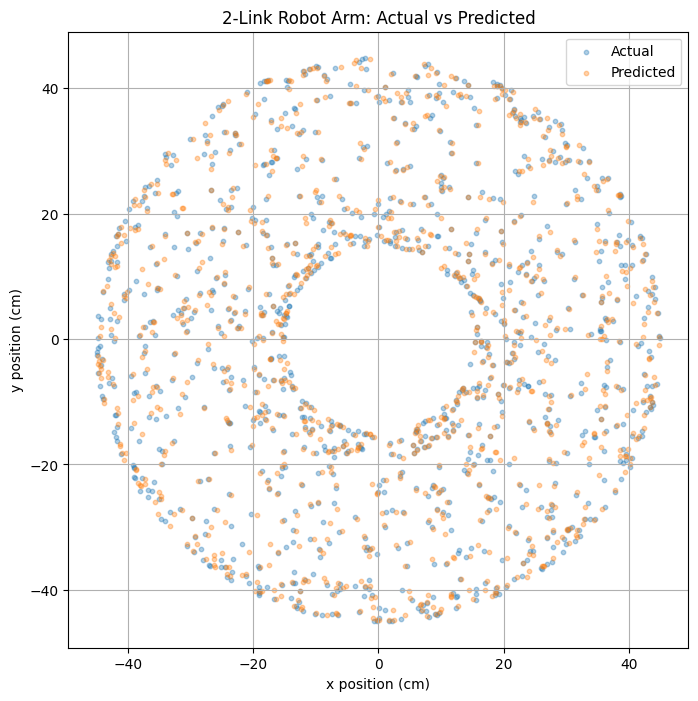

In [15]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test["x_cm"],
    y_test["y_cm"],
    s=10,
    alpha=0.35,
    label="Actual"

)

plt.scatter(
    y_pred[:,0],
    y_pred[:,1],
    s=10,
    alpha=0.35,
    label="Predicted"
)

plt.title("2-Link Robot Arm: Actual vs Predicted")
plt.xlabel("x position (cm)")
plt.ylabel("y position (cm)")

plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

In [16]:
print("Y_test" in globals())
print("Y_pred" in globals())


False
False


In [17]:
from sklearn.metrics import r2_score

r2_x = r2_score(y_test["x_cm"], y_pred[:, 0])
r2_y = r2_score(y_test["y_cm"], y_pred[:, 1])
r2_overall = r2_score(
    y_test,
    y_pred,
    multioutput="variance_weighted"
)

print(f"R² for X-coordinate: {r2_x:.4f}")
print(f"R² for Y-coordinate: {r2_y:.4f}")
print(f"Overall R²:           {r2_overall:.4f}")

R² for X-coordinate: 0.9995
R² for Y-coordinate: 0.9993
Overall R²:           0.9994


In [18]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

print("Linear Regression Training Completed !!!")

Linear Regression Training Completed !!!


In [19]:
y_pred_linear = linear_model.predict(x_test)

print("Prediction shape:", y_pred_linear.shape)

Prediction shape: (1000, 2)


In [20]:
from sklearn.metrics import mean_absolute_error

mae_x_linear = mean_absolute_error(
    y_test["x_cm"],
    y_pred_linear[:, 0]
)

mae_y_linear = mean_absolute_error(
    y_test["y_cm"],
    y_pred_linear[:, 1]
)

mae_overall_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

print(f"Linear Regression MAE for x: {mae_x_linear:.4f} cm")
print(f"Linear Regression MAE for y: {mae_y_linear:.4f} cm")
print(f"Linear Regression Overall MAE: {mae_overall_linear:.4f} cm")

Linear Regression MAE for x: 20.7124 cm
Linear Regression MAE for y: 14.1736 cm
Linear Regression Overall MAE: 17.4430 cm


In [21]:
from sklearn.metrics import r2_score

r2_x_linear = r2_score(y_test["x_cm"], y_pred_linear[:, 0])
r2_y_linear = r2_score(y_test["y_cm"], y_pred_linear[:, 1])
r2_overall_linear = r2_score(
    y_test,
    y_pred_linear,
    multioutput="variance_weighted"
)

print(f"Linear Regression R² for x: {r2_x_linear:.4f}")
print(f"Linear Regression R² for y: {r2_y_linear:.4f}")
print(f"Linear Regression Overall R²: {r2_overall_linear:.4f}")

Linear Regression R² for x: -0.0011
Linear Regression R² for y: 0.4672
Linear Regression Overall R²: 0.2291


In [22]:
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

In [23]:
svr_model = MultiOutputRegressor(SVR(
    kernel="rbf",
    C=100,
    gamma="scale",
    epsilon=0.1
     )
)
print("SVR Model Created!!!")

SVR Model Created!!!


In [24]:
svr_model.fit(x_train, y_train)
print("SVR Training Completed!!!")

SVR Training Completed!!!


In [25]:
y_pred_svr = svr_model.predict(x_test)
print("Prediction shape:",y_pred_svr.shape)

Prediction shape: (1000, 2)


In [26]:
from sklearn.metrics import mean_absolute_error

mae_x_svr = mean_absolute_error(
    y_test["x_cm"],
    y_pred_svr[:, 0]
)

mae_y_svr = mean_absolute_error(
    y_test["y_cm"],
    y_pred_svr[:, 1]
)

mae_overall_svr = mean_absolute_error(
    y_test,
    y_pred_svr
)

print(f"SVR MAE for x: {mae_x_svr:.4f} cm")
print(f"SVR MAE for y: {mae_y_svr:.4f} cm")
print(f"SVR Overall MAE: {mae_overall_svr:.4f} cm")

SVR MAE for x: 0.0547 cm
SVR MAE for y: 0.0517 cm
SVR Overall MAE: 0.0532 cm


In [27]:
from sklearn.metrics import r2_score

r2_x_svr = r2_score(
    y_test["x_cm"],
    y_pred_svr[:, 0]
)

r2_y_svr = r2_score(
    y_test["y_cm"],
    y_pred_svr[:, 1]
)

r2_overall_svr = r2_score(
    y_test,
    y_pred_svr,
    multioutput="variance_weighted"
)

print(f"SVR R² for x: {r2_x_svr:.4f}")
print(f"SVR R² for y: {r2_y_svr:.4f}")
print(f"SVR Overall R²: {r2_overall_svr:.4f}")

SVR R² for x: 1.0000
SVR R² for y: 1.0000
SVR Overall R²: 1.0000


In [28]:
from sklearn.neural_network import MLPRegressor

In [29]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64,64),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)
print("MLP Model Created!!!")

MLP Model Created!!!


In [30]:
mlp_model.fit(x_train, y_train)
print("MLP Training Completed!!!")

MLP Training Completed!!!


In [31]:
y_pred_mlp = mlp_model.predict(x_test)
print("Prediction Shape:", y_pred_mlp.shape)

Prediction Shape: (1000, 2)


In [32]:
from sklearn.metrics import mean_absolute_error

mae_x_mlp = mean_absolute_error(
    y_test["x_cm"],
    y_pred_mlp[:, 0]
)

mae_y_mlp = mean_absolute_error(
    y_test["y_cm"],
    y_pred_mlp[:, 1]
)

mae_overall_mlp = mean_absolute_error(
    y_test,
    y_pred_mlp
)

print(f"MLP MAE for x: {mae_x_mlp:.4f} cm")
print(f"MLP MAE for y: {mae_y_mlp:.4f} cm")
print(f"MLP Overall MAE: {mae_overall_mlp:.4f} cm")

MLP MAE for x: 0.2419 cm
MLP MAE for y: 0.2620 cm
MLP Overall MAE: 0.2520 cm


In [33]:
from sklearn.metrics import r2_score

r2_x_mlp = r2_score(
    y_test["x_cm"],
    y_pred_mlp[:, 0]
)

r2_y_mlp = r2_score(
    y_test["y_cm"],
    y_pred_mlp[:, 1]
)

r2_overall_mlp = r2_score(
    y_test,
    y_pred_mlp,
    multioutput="variance_weighted"
)

print(f"MLP R² for x: {r2_x_mlp:.4f}")
print(f"MLP R² for y: {r2_y_mlp:.4f}")
print(f"MLP Overall R²: {r2_overall_mlp:.4f}")

MLP R² for x: 0.9998
MLP R² for y: 0.9996
MLP Overall R²: 0.9997


In [34]:
comparison_models = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "SVR (RBF)",
        "MLP Neural Network"
    ],
    "MAE_cm": [
        mae_overall_linear,
        mae_total,
        mae_overall_svr,
        mae_overall_mlp
    ],
    "MAE_mm": [
        mae_overall_linear * 10,
        mae_total * 10,
        mae_overall_svr * 10,
        mae_overall_mlp * 10
    ],
    "R2": [
        r2_overall_linear,
        r2_overall,
        r2_overall_svr,
        r2_overall_mlp
    ]
})

comparison_models

,Model,MAE_cm,MAE_mm,R2
0,Linear Regression,17.443008,174.430077,0.229076
1,Random Forest,0.411873,4.118729,0.999411
2,SVR (RBF),0.053189,0.531888,0.999993
3,MLP Neural Network,0.251979,2.519786,0.999724


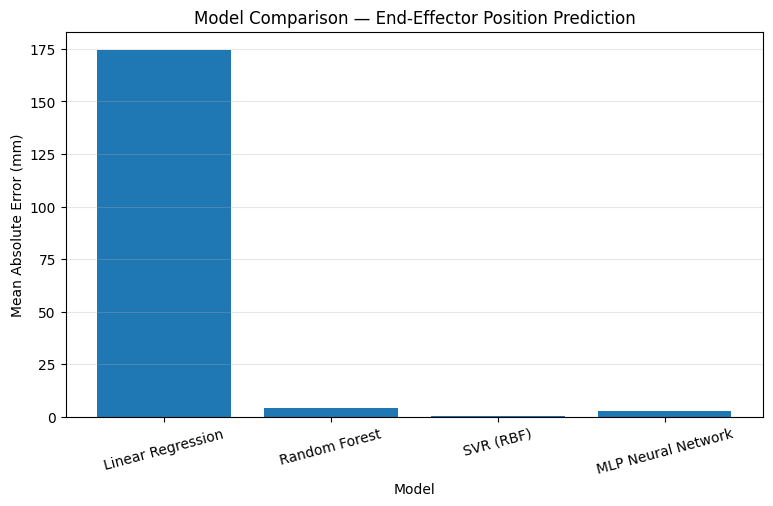

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    comparison_models["Model"],
    comparison_models["MAE_mm"]
)

plt.ylabel("Mean Absolute Error (mm)")
plt.xlabel("Model")
plt.title("Model Comparison — End-Effector Position Prediction")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.show()

 # Version 3 — Sensor Noise ***Robustness***

In [36]:
 # Version 3 — Sensor Noise Robustness

In [37]:
## Objective

##Investigate how simulated joint-angle measurement noise affects
##end-effector position prediction.

##The original forward-kinematics positions are treated as ground truth,
##while Gaussian noise is added to the joint-angle inputs.

In [38]:
# Version 3 — Simulated sensor noise

np.random.seed(42)

noise_std_deg = 1.0
noise_std_rad = np.deg2rad(noise_std_deg)

q1_noisy = q1 + np.random.normal(0, noise_std_rad, n_samples)
q2_noisy = q2 + np.random.normal(0, noise_std_rad, n_samples)

print("Sensor noise standard deviation:", noise_std_deg, "degree")
print("Sensor noise standard deviation:", noise_std_rad, "radians")

Sensor noise standard deviation: 1.0 degree
Sensor noise standard deviation: 0.017453292519943295 radians


In [39]:
noise_q1 = q1_noisy - q1
noise_q2 = q2_noisy - q2

print("Actual q1:", q1[:5])
print("Noisy q1:", q1_noisy[:5])

print("\nActual q2:", q2[:5])
print("Noisy q2:", q2_noisy[:5])

Actual q1: [-0.78828768  2.83192151  1.45766093  0.61988954 -2.16129862]
Noisy q1: [-0.77961838  2.82950834  1.46896522  0.64647142 -2.16538537]

Actual q2: [-0.66830774 -0.16690867  2.22768697 -1.00528209  2.32257747]
Noisy q2: [-0.67570374 -0.17482224  2.19634709 -1.01104325  2.33536775]


In [40]:
print("Mean q1 noise:", np.mean(noise_q1))
print("Std q1 noise:", np.std(noise_q1))

print("\nMean q2 noise:", np.mean(noise_q2))
print("Std q2 noise:", np.std(noise_q2))

Mean q1 noise: 9.777212449467931e-05
Std q1 noise: 0.01739011467027263

Mean q2 noise: -0.00017233200958843205
Std q2 noise: 0.01763369037745596


In [41]:
x_noisy = pd.DataFrame({
    "q1_rad": q1_noisy,
    "q2_rad": q2_noisy

})
x_test_noisy =x_noisy.loc[x_test.index]

print("Noisy test data shape:", x_test_noisy.shape)
print("\nFirst 5 noisy test samples:")
print(x_test_noisy.head())

Noisy test data shape: (1000, 2)

First 5 noisy test samples:
        q1_rad    q2_rad
1501 -0.140424 -2.659661
2586 -2.713637 -0.536826
2653 -2.794649  1.970774
1055 -0.949727 -0.017906
705   3.089088 -1.508645


In [44]:
y_pred_rf_noisy = model.predict(x_test_noisy)

print("First 5 predictions using noisy angles")
print(y_pred_rf_noisy[:5])

First 5 predictions using noisy angles
[[ 15.75078776  -9.14830869]
 [-41.73247331 -10.34936548]
 [-18.48005871 -21.65872458]
 [ 23.88808238 -37.75624408]
 [-30.58438726  16.38900995]]


In [45]:
mae_rf_noisy = mean_absolute_error(y_test,y_pred_rf_noisy)
r2_rf_noisy = r2_score(y_test,y_pred_rf_noisy,multioutput="variance_weighted")

print("Random Forest with noisy input")
print("MAE:", mae_rf_noisy, "cm")
print("MAE:", mae_rf_noisy*10, "mm")
print("R²:",r2_rf_noisy)

Random Forest with noisy input
MAE: 0.535521883608501 cm
MAE: 5.35521883608501 mm
R²: 0.9990644977159848


In [47]:
y_pred_linear_noisy = linear_model.predict(x_test_noisy)

mae_linear_noisy = mean_absolute_error(y_test, y_pred_linear_noisy)
r2_linear_noisy = r2_score(
    y_test,
    y_pred_linear_noisy,
    multioutput="variance_weighted"
)

print("Linear Regression with noisy input")
print("MAE:", mae_linear_noisy, "cm")
print("MAE:", mae_linear_noisy * 10, "mm")
print("R²:", r2_linear_noisy)

Linear Regression with noisy input
MAE: 17.443863634865764 cm
MAE: 174.43863634865764 mm
R²: 0.22896512654102913


In [48]:
y_pred_svr_noisy = svr_model.predict(x_test_noisy)

mae_svr_noisy = mean_absolute_error(y_test, y_pred_svr_noisy)
r2_svr_noisy = r2_score(
    y_test,
    y_pred_svr_noisy,
    multioutput="variance_weighted"
)

print("SVR with noisy input")
print("MAE:", mae_svr_noisy, "cm")
print("MAE:", mae_svr_noisy * 10, "mm")
print("R²:", r2_svr_noisy)

SVR with noisy input
MAE: 0.33454265423693885 cm
MAE: 3.3454265423693883 mm
R²: 0.9996347464176615


In [49]:
y_pred_mlp_noisy = mlp_model.predict(x_test_noisy)

mae_mlp_noisy = mean_absolute_error(y_test, y_pred_mlp_noisy)
r2_mlp_noisy = r2_score(
    y_test,
    y_pred_mlp_noisy,
    multioutput="variance_weighted"
)

print("MLP with noisy input")
print("MAE:", mae_mlp_noisy, "cm")
print("MAE:", mae_mlp_noisy * 10, "mm")
print("R²:", r2_mlp_noisy)

MLP with noisy input
MAE: 0.4290485592250939 cm
MAE: 4.290485592250938 mm
R²: 0.9993797481209598


In [50]:
v3_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "SVR (RBF)",
        "MLP Neural Network"
    ],
    "Clean_MAE_cm": [
        17.443008,
        0.411873,
        0.053189,
        0.251979
    ],
    "Noisy_MAE_cm": [
        mae_linear_noisy,
        mae_rf_noisy,
        mae_svr_noisy,
        mae_mlp_noisy
    ],
    "Clean_R2": [
        0.229076,
        0.999411,
        0.999993,
        0.999724
    ],
    "Noisy_R2": [
        r2_linear_noisy,
        r2_rf_noisy,
        r2_svr_noisy,
        r2_mlp_noisy
    ]
})

v3_results["Clean_MAE_mm"] = v3_results["Clean_MAE_cm"] * 10
v3_results["Noisy_MAE_mm"] = v3_results["Noisy_MAE_cm"] * 10

v3_results

,Model,Clean_MAE_cm,Noisy_MAE_cm,Clean_R2,Noisy_R2,Clean_MAE_mm,Noisy_MAE_mm
0,Linear Regression,17.443008,17.443864,0.229076,0.228965,174.43008,174.438636
1,Random Forest,0.411873,0.535522,0.999411,0.999064,4.11873,5.355219
2,SVR (RBF),0.053189,0.334543,0.999993,0.999635,0.53189,3.345427
3,MLP Neural Network,0.251979,0.429049,0.999724,0.999380,2.51979,4.290486


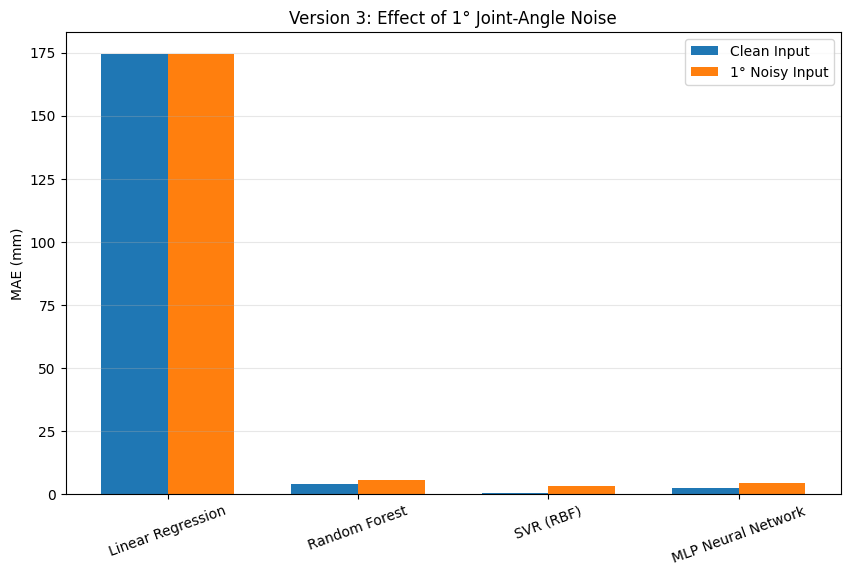

In [51]:
plt.figure(figsize=(10, 6))

x_pos = np.arange(len(v3_results))
width = 0.35

plt.bar(
    x_pos - width/2,
    v3_results["Clean_MAE_mm"],
    width,
    label="Clean Input"
)

plt.bar(
    x_pos + width/2,
    v3_results["Noisy_MAE_mm"],
    width,
    label="1° Noisy Input"
)

plt.xticks(x_pos, v3_results["Model"], rotation=20)
plt.ylabel("MAE (mm)")
plt.title("Version 3: Effect of 1° Joint-Angle Noise")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

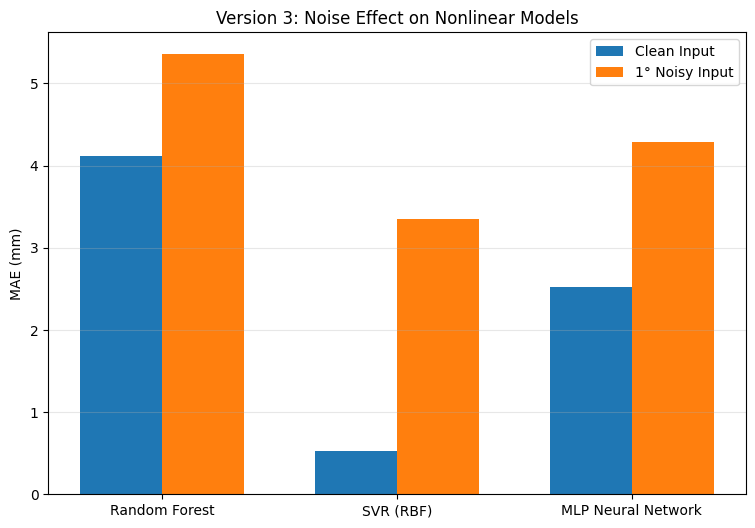

In [52]:
nonlinear_results = v3_results[
    v3_results["Model"] != "Linear Regression"
]

plt.figure(figsize=(9, 6))

x_pos = np.arange(len(nonlinear_results))
width = 0.35

plt.bar(
    x_pos - width/2,
    nonlinear_results["Clean_MAE_mm"],
    width,
    label="Clean Input"
)

plt.bar(
    x_pos + width/2,
    nonlinear_results["Noisy_MAE_mm"],
    width,
    label="1° Noisy Input"
)

plt.xticks(x_pos, nonlinear_results["Model"])
plt.ylabel("MAE (mm)")
plt.title("Version 3: Noise Effect on Nonlinear Models")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()